# Embedding ensemble (stage 2 of 3)

This is the second of three experiments behind the Rethicsec scam classifier. Stage 1 set a lexical baseline. This stage asks whether modelling the meaning of a message, not just its keywords, does better. It adds multilingual e5-small sentence embeddings and combines them with the lexical model in soft-voting and stacking ensembles. The classifier still labels a short message as advance_fee_fraud, mobile_money_fraud, phishing, or not_a_scam.

**Where this notebook sits**

| Stage | Notebook | What it answers | Live API |
|---|---|---|---|
| 1 | initial_demo | Can a simple lexical model classify these messages at all? | wadotuh-scam-classifier-api-initial.hf.space |
| **2** | **embed_demo (this notebook)** | **Does adding sentence-embedding meaning beat the lexical baseline?** | **wadotuh-scam-classifier-api-embed.hf.space** |
| 3 | final_model | After adding African data, which model ships? | wadotuh-scam-classifier-api-final.hf.space |

The full reasoning behind the three notebooks is in [`ml/README.md`](../../README.md).

This notebook runs on the first corpus (English and Portuguese). The labels are source-provenance labels; the human inter-rater study is the final standard (Objective 3).

## 1 · Data engineering

In [1]:
import sys, json
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from types import SimpleNamespace
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score,
                             precision_recall_fscore_support)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# === Self-contained pipeline (this notebook owns its code + artifacts) ==========
ML_ROOT = Path.cwd().parent.parent                       # ml/
HERE = Path.cwd()                                        # notebooks/embed_demo/
DATA = ML_ROOT / "data" / "labelled" / "demo_labeled.jsonl"
MODELS = HERE
CLASS_ORDER = ["advance_fee_fraud", "mobile_money_fraud", "phishing", "not_a_scam"]
SEED = 42

# --- lexical baseline (TF-IDF) -------------------------------------------------
def load_df(path: Path = DATA) -> pd.DataFrame:
    rows = [json.loads(l) for l in path.read_text(encoding="utf-8").splitlines() if l.strip()]
    return pd.DataFrame(rows)

def split(df):
    train, temp = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["category"])
    dev, test = train_test_split(temp, test_size=0.50, random_state=SEED, stratify=temp["category"])
    return train, dev, test

def _vectorizer():
    return TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2,
                           sublinear_tf=True, strip_accents="unicode", max_features=30000)

def build_pipelines():
    return {
        "tfidf_logreg": Pipeline([("tfidf", _vectorizer()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=4.0))]),
        "tfidf_rf": Pipeline([("tfidf", _vectorizer()),
            ("clf", RandomForestClassifier(n_estimators=500, class_weight="balanced",
                                           n_jobs=-1, random_state=SEED))]),
    }

# --- semantic upgrade (e5 embeddings) + ensemble -------------------------------
EMB_MODEL = "intfloat/multilingual-e5-small"
EMB_PREFIX = "query: "
EMB_CACHE = MODELS / "emb_e5small.npz"

def embed_corpus(df):
    ids = df["id"].tolist()
    if EMB_CACHE.exists():
        d = np.load(EMB_CACHE, allow_pickle=True)
        cache = {str(i): v for i, v in zip(d["ids"], d["emb"])}
        if all(i in cache for i in ids):
            print(f"[embed] loaded {len(cache)} cached {EMB_MODEL} vectors")
            return cache
    from sentence_transformers import SentenceTransformer
    print(f"[embed] encoding {len(ids)} messages with {EMB_MODEL} (first run downloads ~470MB)...")
    model = SentenceTransformer(EMB_MODEL)
    vecs = model.encode([EMB_PREFIX + t for t in df["text"].tolist()], batch_size=64,
                        show_progress_bar=True, normalize_embeddings=True)
    MODELS.mkdir(parents=True, exist_ok=True)
    np.savez(EMB_CACHE, ids=np.array(ids, dtype=object), emb=np.asarray(vecs, dtype=np.float32))
    return {i: v for i, v in zip(ids, vecs)}

def emb_matrix(df, id2vec):
    return np.vstack([id2vec[i] for i in df["id"].tolist()])

def proba_aligned(model, X):
    p = model.predict_proba(X)
    classes = list(model.classes_)
    return p[:, [classes.index(c) for c in CLASS_ORDER]]

def metrics(y_true, y_pred):
    f = f1_score(y_true, y_pred, labels=CLASS_ORDER, average=None, zero_division=0)
    return {"accuracy": float(accuracy_score(y_true, y_pred)),
            "macro_f1": float(f1_score(y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0)),
            "per_class": {c: float(f[i]) for i, c in enumerate(CLASS_ORDER)}}

MEMBERS = ["tfidf_logreg", "emb_logreg", "emb_rf"]
ORDER = ["tfidf_logreg", "tfidf_rf", "emb_logreg", "emb_rf", "ensemble_softvote", "ensemble_stack"]

def _X_for(kind, split_df, emb):
    return split_df["text"] if kind == "text" else emb

def train_and_eval(df=None):
    if df is None:
        df = load_df()
    train, dev, test = split(df)
    id2vec = embed_corpus(df)
    Xtr_e, Xdv_e, Xte_e = (emb_matrix(d, id2vec) for d in (train, dev, test))
    ytr, ydv, yte = train["category"], dev["category"], test["category"]
    base = {}
    for name, pipe in build_pipelines().items():
        pipe.fit(train["text"], ytr); base[name] = (pipe, "text")
    emb_lr = LogisticRegression(max_iter=4000, class_weight="balanced", C=8.0); emb_lr.fit(Xtr_e, ytr)
    base["emb_logreg"] = (emb_lr, "emb")
    emb_rf = RandomForestClassifier(n_estimators=500, class_weight="balanced", n_jobs=-1, random_state=SEED)
    emb_rf.fit(Xtr_e, ytr); base["emb_rf"] = (emb_rf, "emb")
    def members_proba(split_df, emb):
        return [proba_aligned(base[m][0], _X_for(base[m][1], split_df, emb)) for m in MEMBERS]
    sv_test = np.mean(members_proba(test, Xte_e), axis=0)
    softvote_pred = [CLASS_ORDER[i] for i in sv_test.argmax(1)]
    meta = LogisticRegression(max_iter=4000, class_weight="balanced")
    meta.fit(np.hstack(members_proba(dev, Xdv_e)), ydv)
    stack_pred = list(meta.predict(np.hstack(members_proba(test, Xte_e))))
    results = {name: metrics(yte, model.predict(_X_for(kind, test, Xte_e)))
               for name, (model, kind) in base.items()}
    results["ensemble_softvote"] = metrics(yte, softvote_pred)
    results["ensemble_stack"] = metrics(yte, stack_pred)
    best = max(results, key=lambda n: results[n]["macro_f1"])
    return {"df": df, "splits": (train, dev, test), "emb": (Xtr_e, Xdv_e, Xte_e),
            "base": base, "members": MEMBERS, "meta": meta, "results": results,
            "order": ORDER, "best": best, "softvote_proba": sv_test,
            "softvote_pred": softvote_pred, "stack_pred": stack_pred}

def predict_messages(bundle, texts):
    from sentence_transformers import SentenceTransformer
    emb = SentenceTransformer(EMB_MODEL).encode([EMB_PREFIX + t for t in texts], normalize_embeddings=True)
    base = bundle["base"]
    probs = [proba_aligned(base[m][0], texts if base[m][1] == "text" else emb) for m in bundle["members"]]
    avg = np.mean(probs, axis=0)
    out = []
    for row in avg:
        ranked = sorted(zip(CLASS_ORDER, row), key=lambda x: -x[1])
        out.append((ranked[0][0], float(ranked[0][1]), {c: float(p) for c, p in zip(CLASS_ORDER, row)}))
    return out

# keep the `dm.` and `em.` interfaces used throughout this notebook
dm = SimpleNamespace(load_df=load_df, split=split, build_pipelines=build_pipelines,
                     CLASS_ORDER=CLASS_ORDER, MODELS=MODELS, DATA=DATA, SEED=SEED)
em = SimpleNamespace(train_and_eval=train_and_eval, predict_messages=predict_messages,
                     embed_corpus=embed_corpus, metrics=metrics, MEMBERS=MEMBERS, ORDER=ORDER,
                     EMB_MODEL=EMB_MODEL, EMB_PREFIX=EMB_PREFIX, EMB_CACHE=EMB_CACHE,
                     MODELS=MODELS, CLASS_ORDER=CLASS_ORDER)
# ===============================================================================

sns.set_theme(style='whitegrid')
df = dm.load_df()
print(f'{len(df):,} labelled messages | classes = {dm.CLASS_ORDER}')
df.head(4)

4,422 labelled messages | classes = ['advance_fee_fraud', 'mobile_money_fraud', 'phishing', 'not_a_scam']


,id,text,language,category,source
0,c791fe9c85b3,Fifth Third Bank: account confirmation procedure.,en,phishing,nazario_email
1,cdeaa974dff3,Jesus armand really is trying to tell everybod...,en,not_a_scam,uci_sms
2,c81801dbc48c,Todays Vodafone numbers ending with 4865 are s...,en,advance_fee_fraud,mendeley_smishing
3,a414a6b7719e,It has issues right now. Ill fix for her by to...,en,not_a_scam,uci_sms


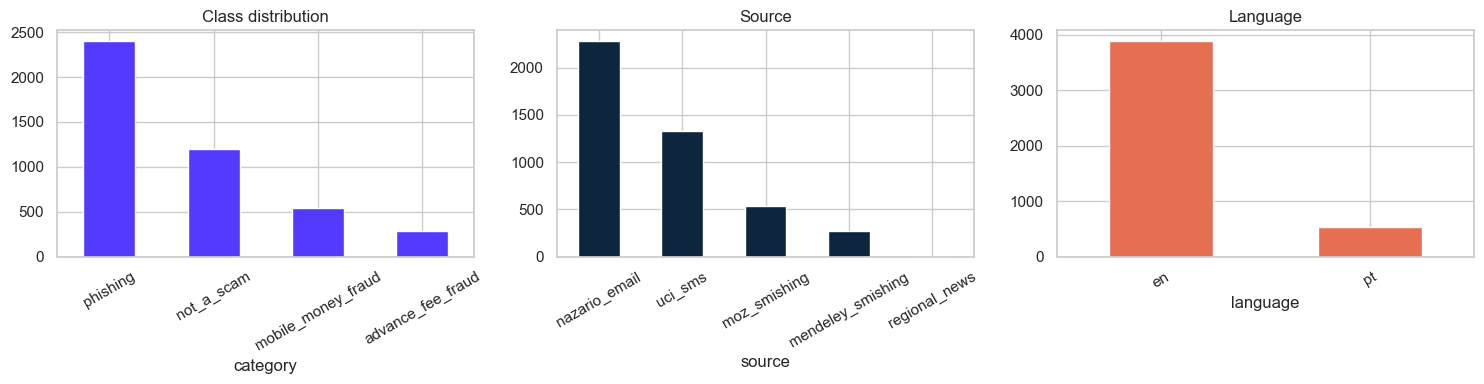

In [2]:
# Corpus shape: class / source / language
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df['category'].value_counts().plot.bar(ax=ax[0], color='#533afd', title='Class distribution')
df['source'].value_counts().plot.bar(ax=ax[1], color='#0d253d', title='Source')
df['language'].value_counts().plot.bar(ax=ax[2], color='#e76f51', title='Language')
for a in ax: a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

**Provenance: which source feeds which class.** The corpus is built from several sources on purpose, so that no single class is tied to one writing style.

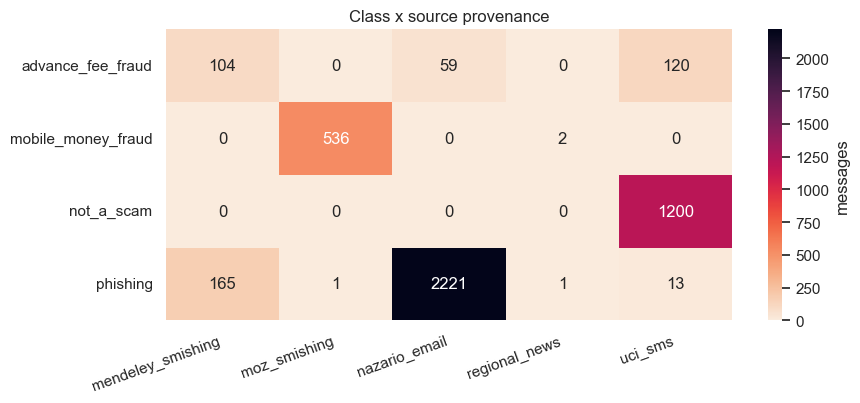

In [3]:
ct = pd.crosstab(df['category'], df['source'])
plt.figure(figsize=(9,4.2))
sns.heatmap(ct, annot=True, fmt='d', cmap='rocket_r', cbar_kws={'label':'messages'})
plt.title('Class x source provenance'); plt.ylabel(''); plt.xlabel('')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## 2 · Two feature representations
**Lexical: TF-IDF.** Word unigrams and bigrams, `min_df=2`, sublinear TF, unicode accent stripping, and a vocabulary capped at 30,000. This is strong when scams reuse give-away phrases such as "verify your account" or "you have won", but it is blind to paraphrase and to wording it has not seen.

**Semantic: multilingual-e5-small.** A sentence-transformer that maps each message (prefixed `"query: "`) to a 384-dimensional vector where meaning, rather than exact words, drives proximity. It covers English, Portuguese, French, and other languages including Swahili, so it generalises across the languages the corpus mixes. The embeddings are cached in `emb_e5small.npz`, so re-runs are fast.

Each representation feeds a Logistic Regression (L2 cross-entropy, `class_weight='balanced'`) and a Random Forest (500 bagged trees). Random Forest is skipped on TF-IDF, where it is weak on high-dimensional sparse input. The protocol is a 70/15/15 stratified split, seed 42, with metrics on the held-out test split only.

## 3 · Train the full ladder
`em.train_and_eval()` fits the four base models and both ensembles in one call. It is the same function the saved model and the serving code use.

In [4]:
bundle = em.train_and_eval(df)
train, dev, test = bundle['splits']
print(f'train {len(train)} / dev {len(dev)} / test {len(test)}')
print('models:', list(bundle['base']) + ['ensemble_softvote', 'ensemble_stack'])
print('ensemble members:', bundle['members'])

[embed] loaded 4422 cached intfloat/multilingual-e5-small vectors


train 3095 / dev 663 / test 664
models: ['tfidf_logreg', 'tfidf_rf', 'emb_logreg', 'emb_rf', 'ensemble_softvote', 'ensemble_stack']
ensemble members: ['tfidf_logreg', 'emb_logreg', 'emb_rf']


**Ensembles.**
- **Soft-voting:** the element-wise mean of the member probability vectors, then arg-max.
- **Stacking:** a meta Logistic Regression trained on the dev-split member probabilities (the bases are fit on train only, so there is no leakage), then applied to the test-split member probabilities.

## 4 · Results: held-out test set

In [5]:
rows = [{'model': n,
         'accuracy': round(bundle['results'][n]['accuracy'], 3),
         'macro_F1': round(bundle['results'][n]['macro_f1'], 3)}
        for n in bundle['order']]
summary = pd.DataFrame(rows).set_index('model'); summary

,accuracy,macro_F1
model,,
tfidf_logreg,0.958,0.943
tfidf_rf,0.950,0.928
emb_logreg,0.953,0.926
emb_rf,0.952,0.910
ensemble_softvote,0.971,0.955
ensemble_stack,0.952,0.925


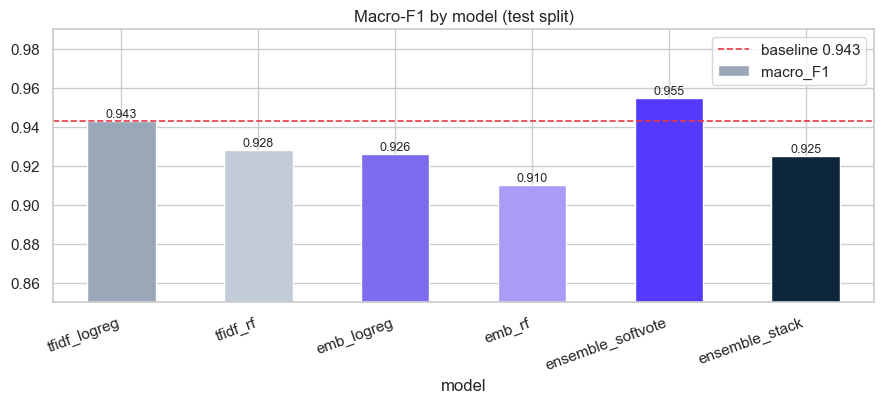

In [6]:
# Macro-F1 across the ladder, baseline marked
base_f1 = summary.loc['tfidf_logreg', 'macro_F1']
colors = ['#9aa7b8','#c2ccd9','#7c6cf0','#a99bf6','#533afd','#0d253d']
ax = summary['macro_F1'].plot.bar(color=colors, figsize=(9,4.2), ylim=(0.85,0.99))
ax.axhline(base_f1, ls='--', color='#e63946', lw=1.2, label=f'baseline {base_f1:.3f}')
for i, v in enumerate(summary['macro_F1']):
    ax.text(i, v+0.002, f'{v:.3f}', ha='center', fontsize=9)
plt.title('Macro-F1 by model (test split)'); plt.xticks(rotation=20, ha='right')
plt.legend(); plt.tight_layout(); plt.show()

**Per-class F1: where each representation wins.** Embeddings lift mobile-money and not-a-scam, TF-IDF holds advance-fee, and the soft-voting ensemble takes the best of both.

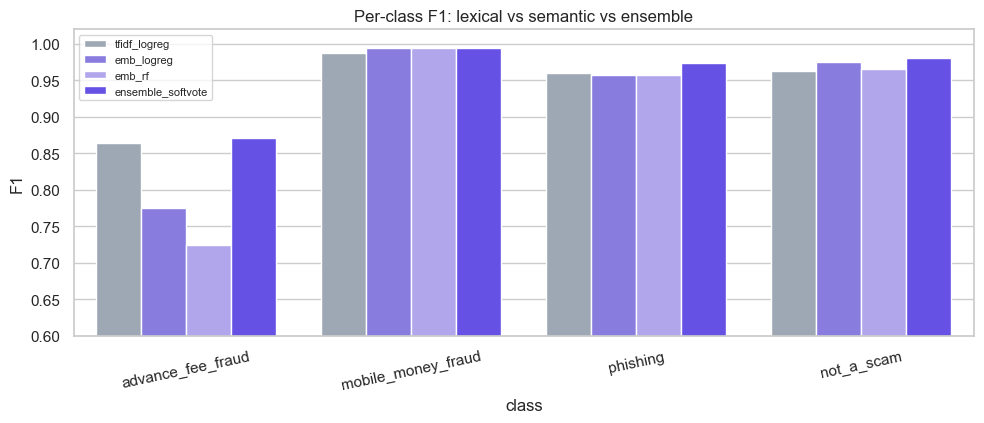

In [7]:
sub = ['tfidf_logreg','emb_logreg','emb_rf','ensemble_softvote']
rowsf = [{'class': c, 'model': n, 'F1': bundle['results'][n]['per_class'][c]}
         for n in sub for c in dm.CLASS_ORDER]
fdf = pd.DataFrame(rowsf)
plt.figure(figsize=(10,4.4))
sns.barplot(data=fdf, x='class', y='F1', hue='model',
            palette=['#9aa7b8','#7c6cf0','#a99bf6','#533afd'])
plt.ylim(0.6,1.02); plt.title('Per-class F1: lexical vs semantic vs ensemble')
plt.xticks(rotation=12); plt.legend(title='', fontsize=8); plt.tight_layout(); plt.show()

**Confusion matrix: the soft-voting ensemble, the best model on this first corpus.**

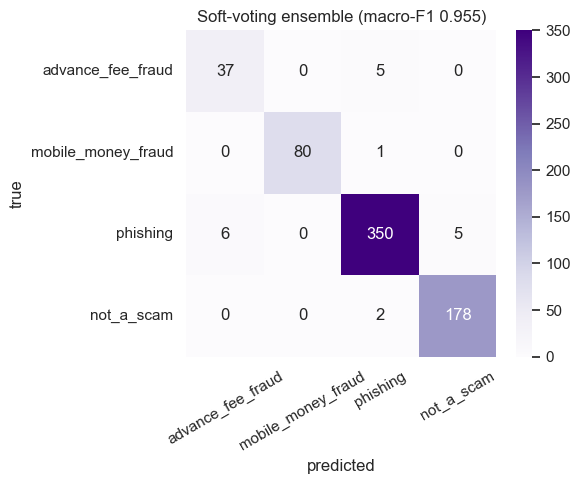

In [8]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test['category'], bundle['softvote_pred'], labels=dm.CLASS_ORDER)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=dm.CLASS_ORDER, yticklabels=dm.CLASS_ORDER)
plt.title(f"Soft-voting ensemble (macro-F1 {bundle['results']['ensemble_softvote']['macro_f1']:.3f})")
plt.xlabel('predicted'); plt.ylabel('true'); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## 5 · Finding
1. **Semantic embeddings alone do not beat the lexical baseline on this corpus.** `emb_logreg` and `emb_rf` land below `tfidf_logreg`. Scam messages here reuse strong give-away keywords that TF-IDF already catches, and the embeddings even hurt the smallest class, advance-fee.
2. **The two representations are complementary.** The embeddings are stronger exactly where wording varies, on mobile-money and benign messages.
3. **The soft-voting ensemble is the best model on this corpus.** It beats the baseline and lifts every class, so on this first corpus it is the one deployed (it is served at the embed API above for comparison).
4. **Stacking under-performs soft-voting.** The meta-learner over-fits the small dev split, while plain averaging generalises better.

**The setback that led to stage 3.** Read per class, this ensemble is still weak on the two classes the app most needs to catch, mobile_money_fraud and advance_fee_fraud, which are also the classes with the fewest training examples. That weakness is what motivated the final stage: gathering real African SMS for those classes and retraining on a larger corpus. See [`../final_model/`](../final_model/).

*Caveat:* these are still source-provenance labels. The human inter-rater-verified corpus is the final evaluation, and the honest, per-class reading above is a stronger claim than any single headline number.

## 6 · Live inference (soft-voting ensemble, multilingual)

In [9]:
examples = [
  'URGENT! Your number won a 2,000,000 prize GUARANTEED. Call 09061790121 to claim now.',
  'Caro cliente, a sua conta M-Pesa foi bloqueada. Envie o seu PIN para reactivar.',
  'Cher client, votre compte bancaire sera suspendu. Cliquez ici pour verifier: http://bit.ly/x9',
  'Hey, are we still on for lunch at 1pm tomorrow?',
]
for t, (label, conf, _) in zip(examples, em.predict_messages(bundle, examples)):
    print(f'{label:20} ({conf:.2f})  <- {t[:66]}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

advance_fee_fraud    (0.91)  <- URGENT! Your number won a 2,000,000 prize GUARANTEED. Call 0906179
mobile_money_fraud   (0.68)  <- Caro cliente, a sua conta M-Pesa foi bloqueada. Envie o seu PIN pa
phishing             (0.81)  <- Cher client, votre compte bancaire sera suspendu. Cliquez ici pour
not_a_scam           (0.91)  <- Hey, are we still on for lunch at 1pm tomorrow?


In [10]:
# Save the artifacts this notebook owns (ensemble bundle + metrics), beside it
base, meta = bundle['base'], bundle['meta']
(MODELS / 'embed_metrics.json').write_text(json.dumps(
    {'embedder': em.EMB_MODEL, 'test': bundle['results'], 'best': bundle['best'],
     'n_train': len(train), 'n_dev': len(dev), 'n_test': len(test)}, indent=2))
joblib.dump({'tfidf_logreg': base['tfidf_logreg'][0],
             'emb_logreg': base['emb_logreg'][0], 'emb_rf': base['emb_rf'][0],
             'stack_meta': meta, 'members': bundle['members'], 'embedder': em.EMB_MODEL,
             'class_order': dm.CLASS_ORDER},
            MODELS / 'embed_models.joblib')
print('saved embed_models.joblib + embed_metrics.json to', MODELS)

saved embed_models.joblib + embed_metrics.json to C:\Users\LENOVO\Desktop\Capstone-Project\ml\notebooks\embed_demo


## 7 · Deployment and next steps
The trained ensemble and its embedder reference are saved next to this notebook as `embed_models.joblib`, with metrics in `embed_metrics.json`. It is served by the matching API in `ml/embed_serve/`, which loads this bundle and the e5 embedder:

```bash
cd ml
python -m uvicorn embed_serve.app:app --reload --port 8000
# open http://127.0.0.1:8000/docs  then  POST /predict
```

Where this leads: the lighter, embedder-free final model in [`../final_model/`](../final_model/), trained on the expanded multilingual corpus, is the model the mobile app actually calls. An admin dashboard that recycles user-reported scams back into the corpus, and a growing set of human-verified labels, will firm up the numbers above.